<a href="https://colab.research.google.com/github/alyPoint/CEFET---Processamento-de-Sinais-I-140826/blob/main/DSP_1_PRATICA_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Prática 2 - Processamento de Sinais 1**

####**Exercício 1**


 Gráfico de 500 Hz 



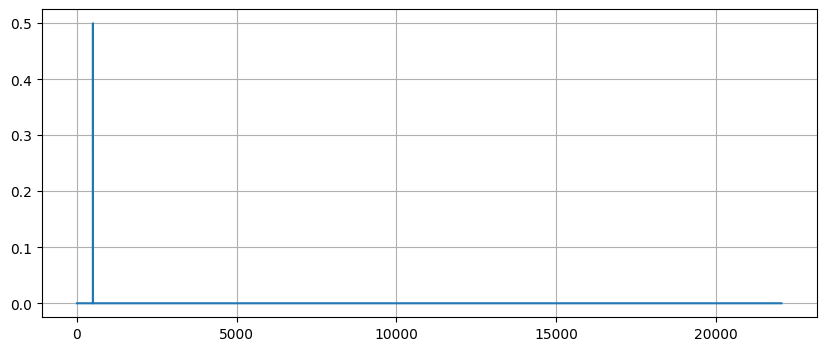


 Gráfico de 1000 Hz 



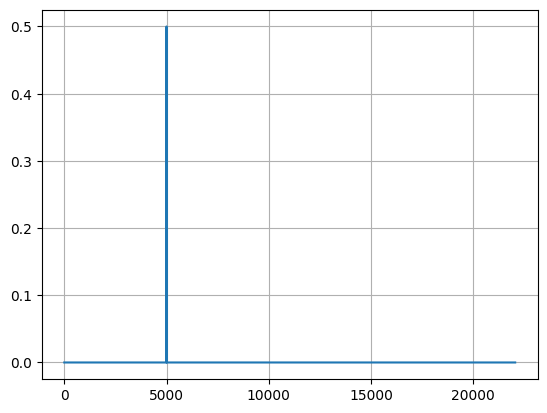


 Gráfico de 10000 Hz 



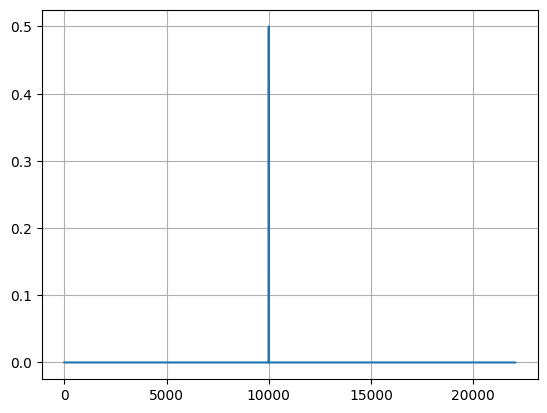


 Gráfico de 50000 Hz 



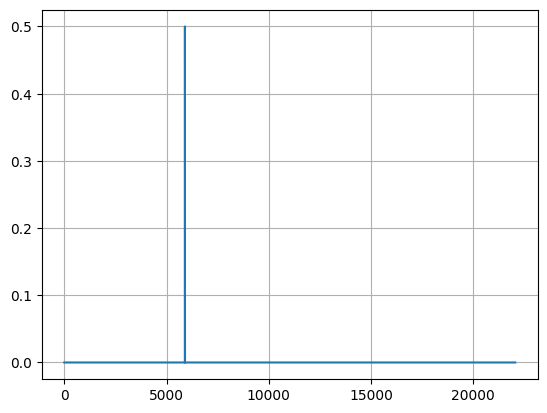

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import scipy.signal as signal

#período com frequência de amostragem
t = 1/44100

#frequência_cosseno = 500
#frequência_amostragem = 44.1 kHz
#duração = 1.0

arr = np.arange (0, 1, t, dtype = None)
xA = np.cos(2 * np.pi * 500 * arr)
xB = np.cos(2 * np.pi * 5000 * arr)
xC = np.cos(2 * np.pi * 10000 * arr)
xD = np.cos(2 * np.pi * 50000 * arr)

frequenciasA, espectroA = signal.periodogram(xA, 44100)
frequenciasB, espectroB = signal.periodogram(xB, 44100)
frequenciasC, espectroC = signal.periodogram(xC, 44100)
frequenciasD, espectroD = signal.periodogram(xD, 44100)

plt.figure(figsize = (10,4))

print("\n Gráfico de 500 Hz \n")
plt.plot(frequenciasA, espectroA)

plt.grid(True)
plt.show()

print("\n Gráfico de 1000 Hz \n")
plt.plot(frequenciasB, espectroB)

plt.grid(True)
plt.show()

print("\n Gráfico de 10000 Hz \n")
plt.plot(frequenciasC, espectroC)

plt.grid(True)
plt.show()

print("\n Gráfico de 50000 Hz \n")
plt.plot(frequenciasD, espectroD)

plt.grid(True)
plt.show()

####**Exercicio 2**

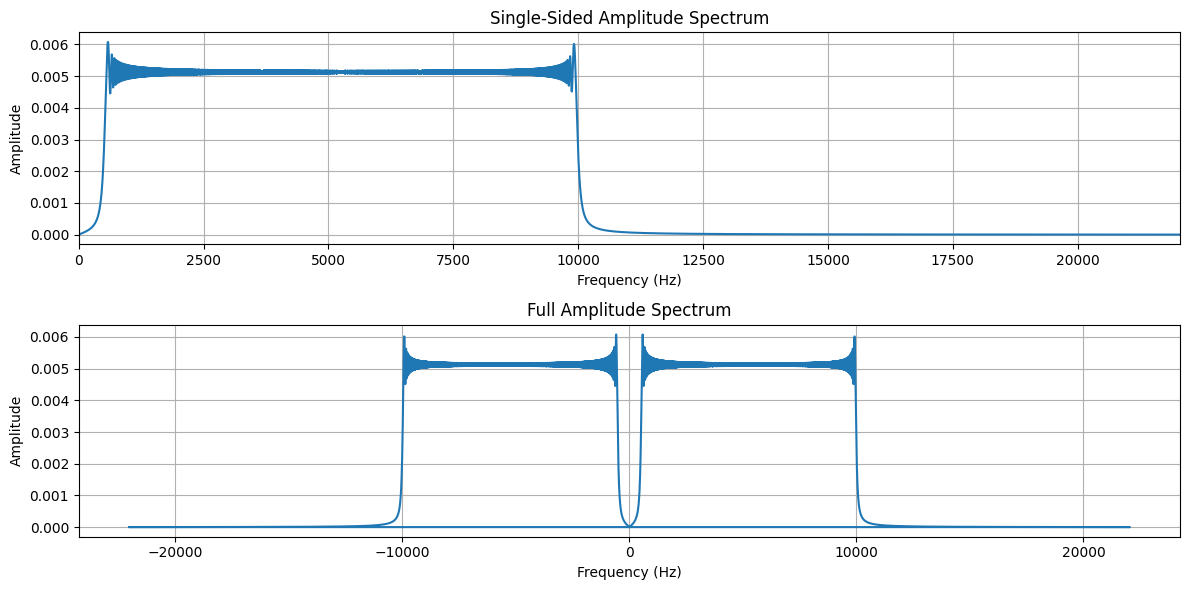

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import chirp
from scipy.fft import fft, fftfreq


fs = 44100                                                           # Frequência de amostragem

# nome do intervalo = np.arange(inicio, fim, passo)
t = np.arange(0, 1, 1/fs)                                            # Intervalo de tempo e amostragem

# nome do sinal = chirp(intervalo de tempo, frequencia inicial, tempo final, frequencia final, método)
sinal = chirp(t, 500, 1, 10000, method = 'linear')

def calculate_spectrum(signal, frequency_sample, single_sided=True):
    N = len(signal) # Number of sample points
    T = 1.0 / 44100 # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes

#0 a 10000
frequencies_single_sided, amplitudes_single_sided = calculate_spectrum(sinal, fs, single_sided=True)

#-10000 a 10000
frequencies_full, amplitudes_full = calculate_spectrum(sinal, fs, single_sided=False)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(frequencies_single_sided, amplitudes_single_sided)
plt.title('Single-Sided Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, fs / 2) # Show frequencies up to Nyquist

plt.subplot(2, 1, 2)
plt.plot(frequencies_full, amplitudes_full)
plt.title('Full Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()

####**Exercicio 3**

Saving handel.wav to handel (2).wav


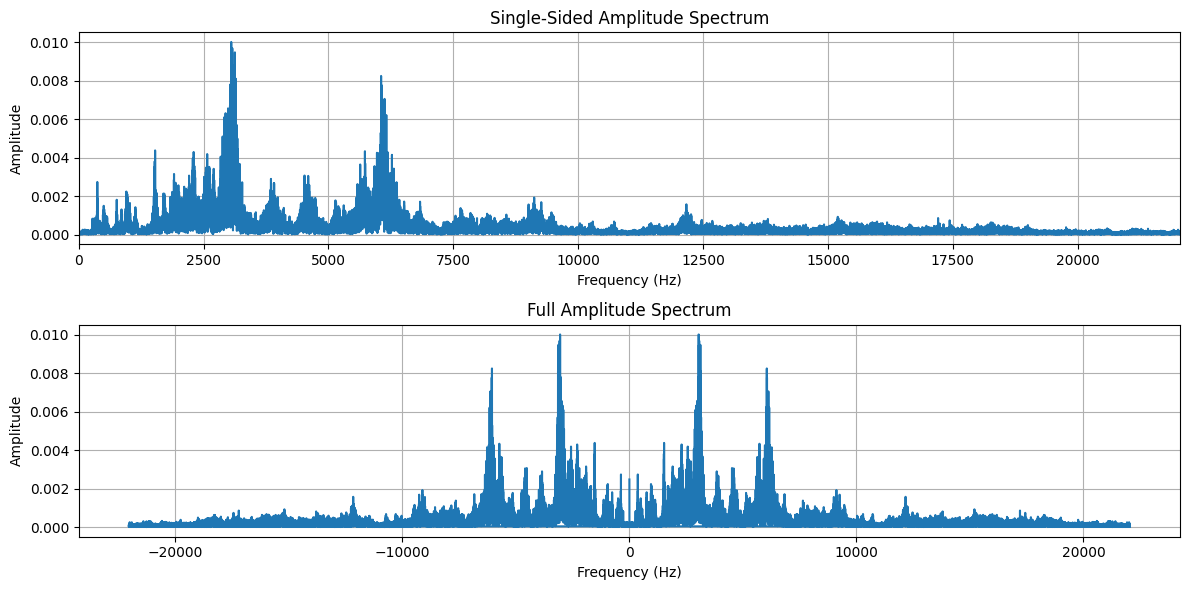

In [ ]:
import numpy as NP
import matplotlib.pyplot as plt
import soundfile as sf
from google.colab import files
from scipy.fft import fft, fftfreq

fs = 44100                                                           # Frequência de amostragem

# nome do intervalo = np.arange(inicio, fim, passo)
t = np.arange(0, 1, 1/fs)                                            # Intervalo de tempo e amostragem

#Part (A) formar gráficos com os sons
files.upload()
audioA, file_fsA = sf.read('handel.wav')
duracao_audioA = len(audioA)/file_fsA

#Calculo
def calculate_spectrum(signal, frequency_sample, single_sided=True):
    N = len(signal) # Number of sample points
    T = 1.0 / 44100 # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes


#0 a 10000
frequencies_single_sided, amplitudes_single_sided = calculate_spectrum(audioA, fs, single_sided=True)

#-10000 a 10000
frequencies_full, amplitudes_full = calculate_spectrum(audioA, fs, single_sided=False)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(frequencies_single_sided, amplitudes_single_sided)
plt.title('Single-Sided Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, fs / 2) # Show frequencies up to Nyquist

plt.subplot(2, 1, 2)
plt.plot(frequencies_full, amplitudes_full)
plt.title('Full Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()

####**Exercicio 4**

Saving handel.wav to handel (14).wav




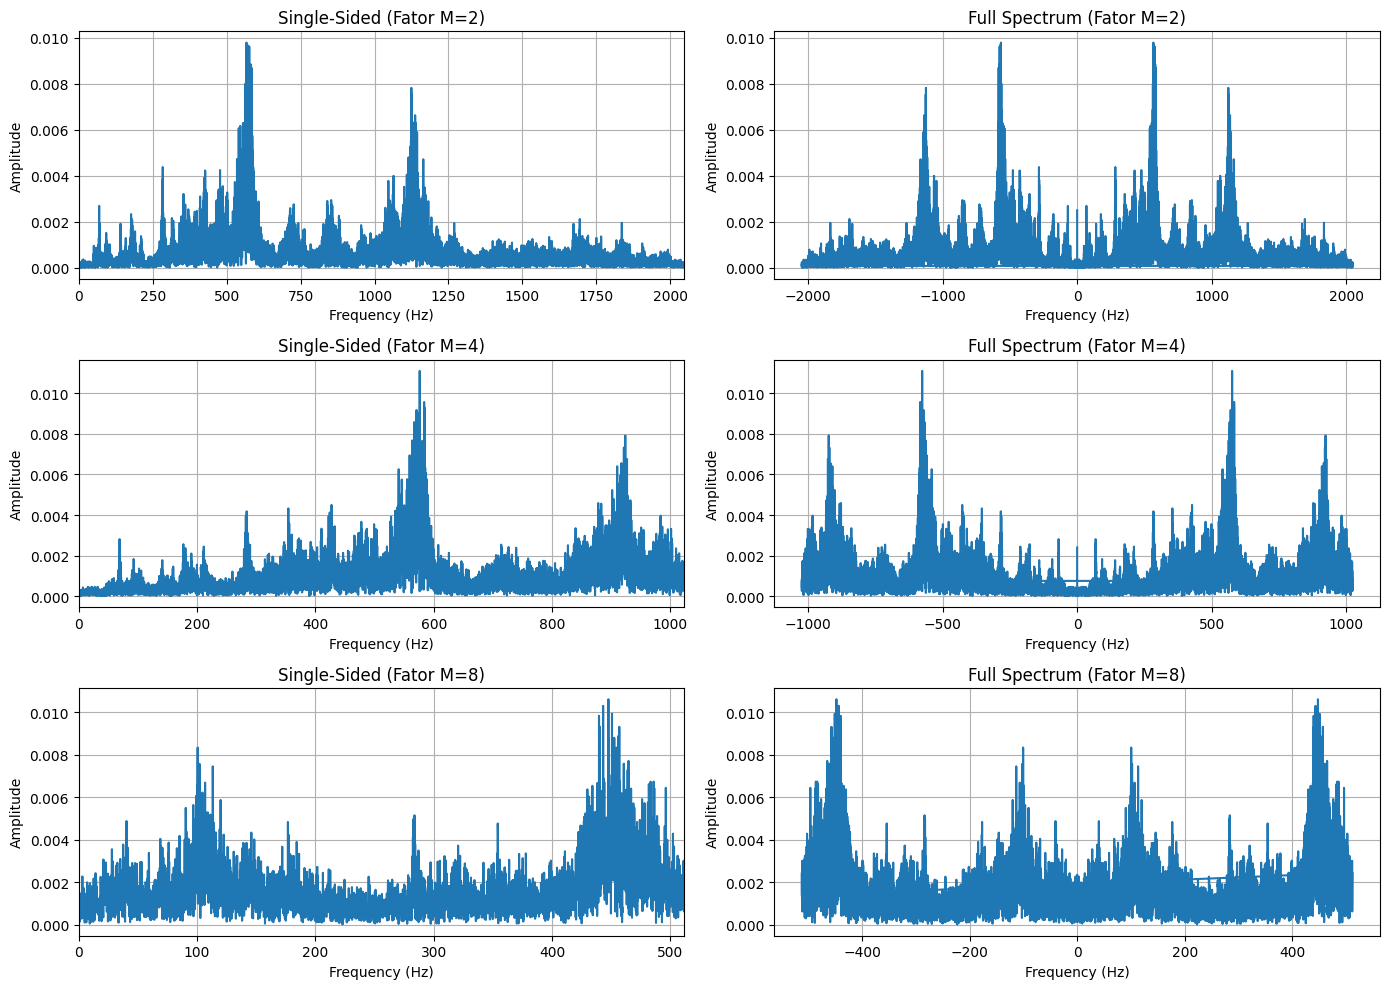



Áudio Fator M = 2 | Taxa original: 4096 Hz | Taxa para reprodução: 44100 Hz | Duração: 8.93 s


Áudio Fator M = 4 | Taxa original: 2048 Hz | Taxa para reprodução: 44100 Hz | Duração: 8.93 s


Áudio Fator M = 8 | Taxa original: 1024 Hz | Taxa para reprodução: 44100 Hz | Duração: 8.93 s


In [15]:
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
from google.colab import files
from IPython.display import Audio, display
from scipy.fft import fft, fftfreq
from scipy.signal import resample_poly
from fractions import Fraction

## Upload do arquivo (feito apenas uma vez)
files.upload()
audioA, file_fsA = sf.read('handel.wav')


## Função de cálculo do espectro mantida
def calculate_spectrum(signal, frequency_sample, single_sided=True):
    N = len(signal)
    T = 1.0 / frequency_sample

    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[: N // 2]
        amplitudes = 1.0 / N * np.abs(yf[: N // 2])
    else:
        xf = fftfreq(N, T)
        amplitudes = 1.0 / N * np.abs(yf)

    return xf, amplitudes


## Fatores de subamostragem desejados
fatores = [2, 4, 8]

print("\n")
## Criando figura com 3 subplots para Single-Sided e 3 para Full Spectrum
plt.figure(figsize=(14, 10))

for i, fator in enumerate(fatores, 1):
    sinal_sub = audioA[::fator]
    nova_taxa = file_fsA / fator

    # Cálculos para o fator atual
    freq_single, amp_single = calculate_spectrum(
        sinal_sub, nova_taxa, single_sided=True
    )
    freq_full, amp_full = calculate_spectrum(
        sinal_sub, nova_taxa, single_sided=False
    )

    # Plot Single-Sided
    plt.subplot(len(fatores), 2, 2 * i - 1)
    plt.plot(freq_single, amp_single)
    plt.title(f'Single-Sided (Fator M={fator})')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.xlim(0, nova_taxa / 2)  # Limite ajustado para a Nyquist de cada fator

    # Plot Full Spectrum
    plt.subplot(len(fatores), 2, 2 * i)
    plt.plot(freq_full, amp_full)
    plt.title(f'Full Spectrum (Fator M={fator})')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.grid(True)

plt.tight_layout()
plt.show()

print("\n")


## Reprodução dos áudios

# Taxa de amostragem utilizada apenas para reprodução
fs_reproducao = 44100

for fator in fatores:
    # Subamostragem original
    sinal = audioA[::fator].copy()

    # Nova taxa de amostragem do sinal subamostrado
    nova_taxa = int(file_fsA / fator)

    fracao = Fraction(fs_reproducao, nova_taxa)

    sinal_reproducao = resample_poly(
        sinal,
        fracao.numerator,
        fracao.denominator,
        axis=0
    )

    # Duração do sinal
    duracao = len(sinal) / nova_taxa

    print(
        f'Áudio Fator M = {fator} | '
        f'Taxa original: {nova_taxa} Hz | '
        f'Taxa para reprodução: {fs_reproducao} Hz | '
        f'Duração: {duracao:.2f} s'
    )

    # Reprodução
    display(
        Audio(
            sinal_reproducao,
            rate=fs_reproducao
        )
    )

####**Exercício 5**

Saving handel.wav to handel (13).wav




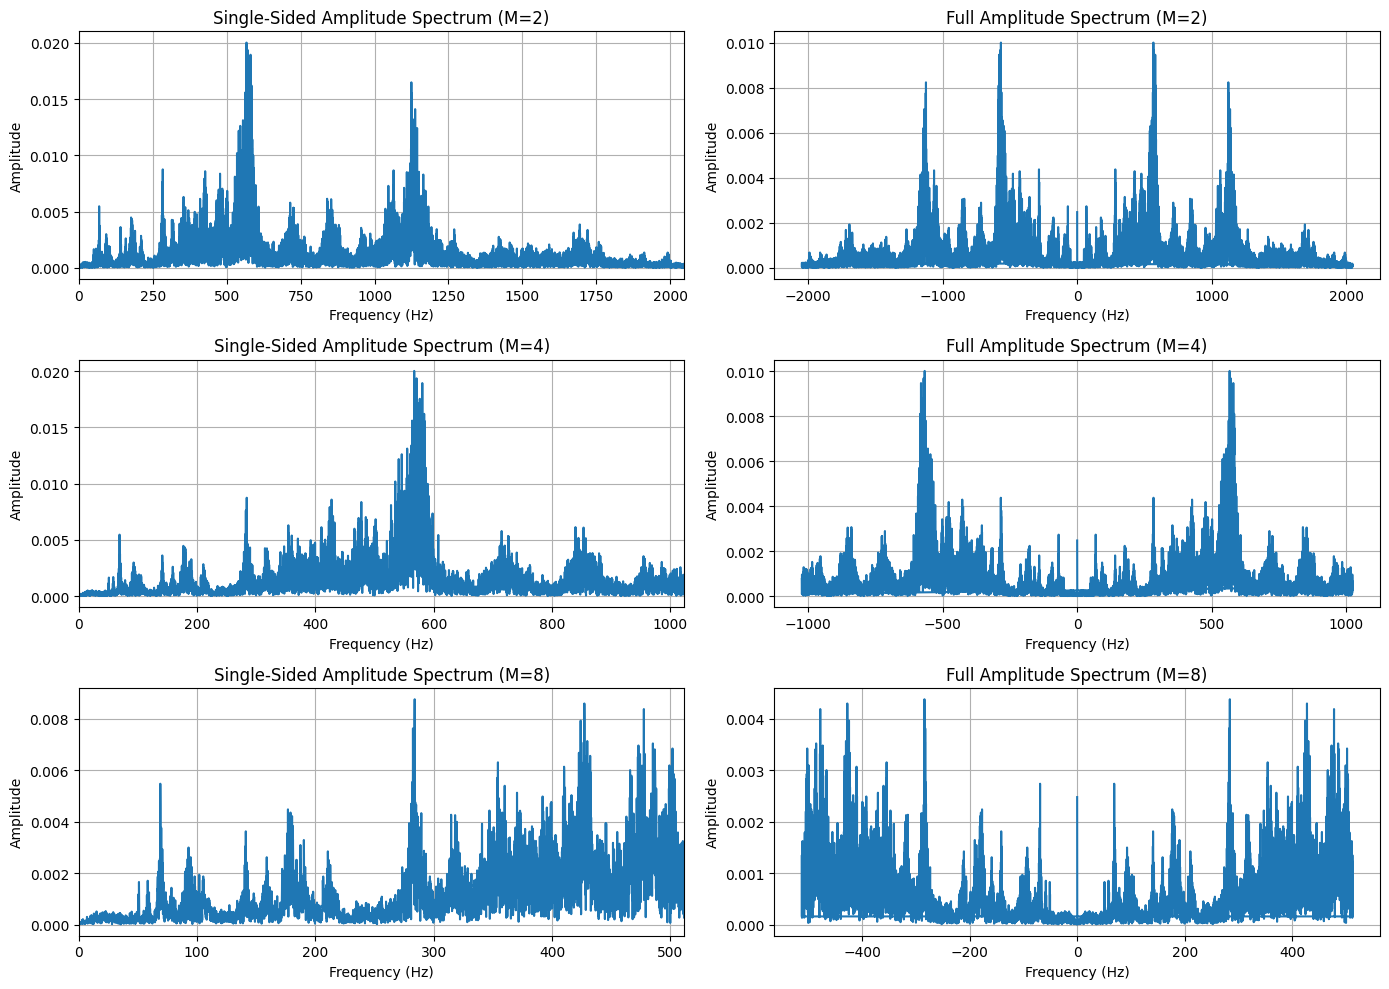



Áudio Fator M = 2 | Taxa original: 4096 Hz | Taxa para reprodução: 44100 Hz | Duração: 8.92 s


Áudio Fator M = 4 | Taxa original: 2048 Hz | Taxa para reprodução: 44100 Hz | Duração: 8.92 s


Áudio Fator M = 8 | Taxa original: 1024 Hz | Taxa para reprodução: 44100 Hz | Duração: 8.92 s


In [14]:
# Bibliotecas
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from IPython.display import Audio, display
from google.colab import files
from scipy.fft import fft, fftfreq
from scipy.signal import resample


# Download do arquivo
files.upload()


# Dados
audio, file_fs = sf.read('handel.wav')

fatores = [2, 4, 8]                     # Fatores de amostragem
fs = 44100                              # Taxa utilizada para reprodução


# REAMOSTRAGEM E CÁLCULO DA FFT
print("\n")

plt.figure(figsize=(14, 10))

for i, fator in enumerate(fatores, 1):

    # Nova taxa de amostragem
    nova_fs = int(file_fs / fator)

    # Número de amostras após a reamostragem
    num_amostras_novo = int(len(audio) / fator)

    # Reamostragem
    sinal_sub = resample(audio, num_amostras_novo)


    # CÁLCULO DA FFT
    N = len(sinal_sub)
    T = 1.0 / nova_fs

    # Executa a FFT no sinal
    yf = fft(sinal_sub, axis=0)


    # Espectro de Lado Único (0 a Nyquist)
    frequencies_single_sided = fftfreq(N, T)[: N // 2]
    amplitudes_single_sided = (
        2.0 / N * np.abs(yf[: N // 2])
    )


    # Espectro Completo (-Nyquist a Nyquist)
    frequencies_full = fftfreq(N, T)
    amplitudes_full = (
        1.0 / N * np.abs(yf)
    )


    # PLOTAGEM DO SINGLE-SIDED
    plt.subplot(len(fatores), 2, 2 * i - 1)

    plt.plot(
        frequencies_single_sided,
        amplitudes_single_sided
    )

    plt.title(f'Single-Sided Amplitude Spectrum (M={fator})')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.xlim(0, nova_fs / 2)


    # PLOTAGEM DO FULL SPECTRUM
    plt.subplot(len(fatores), 2, 2 * i)

    plt.plot(
        frequencies_full,
        amplitudes_full
    )

    plt.title(f'Full Amplitude Spectrum (M={fator})')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.grid(True)


plt.tight_layout()
plt.show()


# REPRODUÇÃO DOS ÁUDIOS
print("\n")

for fator in fatores:

    # Nova taxa de amostragem
    nova_fs = int(file_fs / fator)

    # Número de amostras após a reamostragem
    num_amostras_novo = int(len(audio) / fator)

    # Reamostragem
    sinal_sub = resample(audio, num_amostras_novo)


    # Duração do sinal subamostrado
    duracao = len(sinal_sub) / nova_fs

    ## Adaptação para reprodução no Colab
    # Número de amostras necessário para reproduzir
    # o mesmo áudio em 44100 Hz
    num_amostras_reproducao = int(
        duracao * fs
    )

    sinal_reproducao = resample(
        sinal_sub,
        num_amostras_reproducao
    )


    print(
        f'Áudio Fator M = {fator} | '
        f'Taxa original: {nova_fs} Hz | '
        f'Taxa para reprodução: {fs} Hz | '
        f'Duração: {duracao:.2f} s'
    )


    display(
        Audio(
            sinal_reproducao,
            rate=fs
        )
    )


####**Exercício 6**

####**Exercício 7**

####**Exercício 8 - INCOMPLETO**


 Gráfico letra A 



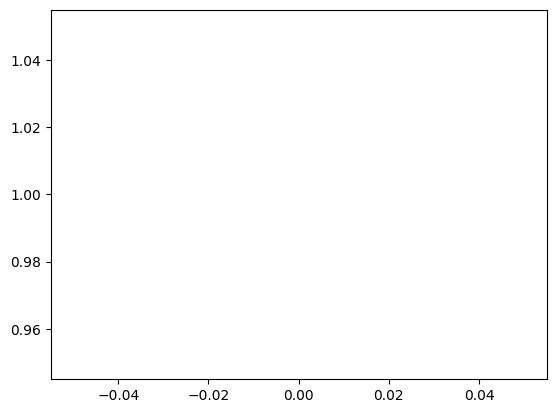


 Gráfico letra B 



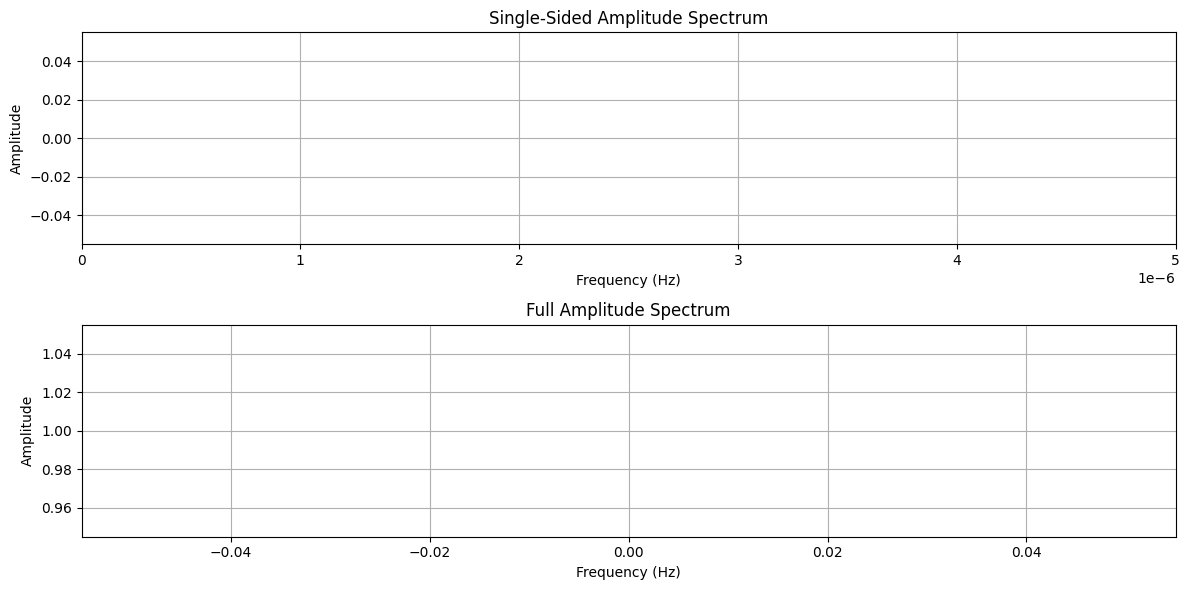


 Gráfico letra C 



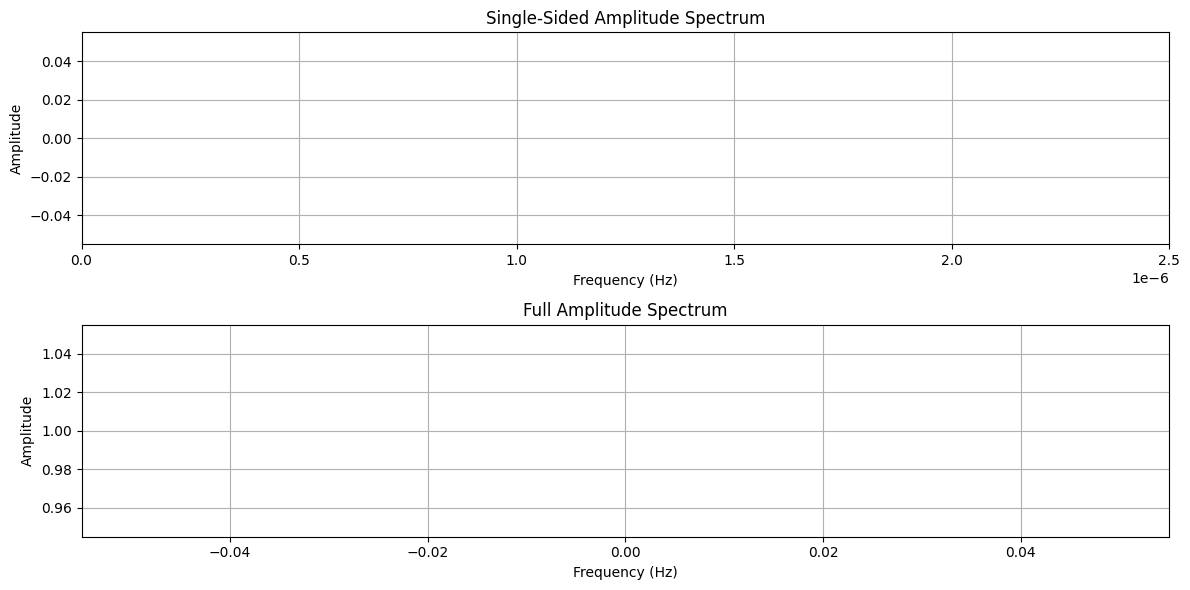

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1.]


/tmp/ipykernel_1153/4256496724.py:131: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  array_de_etapas[I] = np.cos(2000 * np.pi * interval * I) + np.sin (5000 * np.pi * interval * I)


In [ ]:
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt

#Frequência de amostragem 10 MHz
fs = 10 * 10 ** -6
T = 1 / fs

#Duração de 10 milisegundos
t = 1 * 10 ** -3

interval = np.arange (0, t, T, dtype=None)

y = np.cos(2000 * np.pi * interval) + np.sin (5000 * np.pi * interval)

print ("\n Gráfico letra A \n")

plt.plot(interval, y)
plt.show()

#LETRA B) Para calcular o specular

def calculate_spectrumA(signal, frequency_sample, single_sided=True):
    N = len(signal) # Number of sample points
    T = 1.0 / 44100 # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes


#0 a 10000
frequencies_single_sided, amplitudes_single_sided = calculate_spectrumA(y, fs, single_sided=True)

#-10000 a 10000
frequencies_full, amplitudes_full = calculate_spectrumA(y, fs, single_sided=False)

plt.figure(figsize=(12, 6))

print ("\n Gráfico letra B \n")

plt.subplot(2, 1, 1)
plt.plot(frequencies_single_sided, amplitudes_single_sided)
plt.title('Single-Sided Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, fs / 2) # Show frequencies up to Nyquist

plt.subplot(2, 1, 2)
plt.plot(frequencies_full, amplitudes_full)
plt.title('Full Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()

#LETRA C) Com frequência de Nyquist

#Frequência de Nyquist
freq_nyquist = fs/2

def calculate_spectrumB(signal, frequency_sample, single_sided=True):
    N = len(signal) # Number of sample points
    T = 1.0 / 44100 # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes


#0 a 10000
frequencies_single_sided, amplitudes_single_sided = calculate_spectrumB(y, freq_nyquist, single_sided=True)

#-10000 a 10000
frequencies_full, amplitudes_full = calculate_spectrumB(y, freq_nyquist, single_sided=False)

plt.figure(figsize=(12, 6))

print ("\n Gráfico letra C \n")

plt.subplot(2, 1, 1)
plt.plot(frequencies_single_sided, amplitudes_single_sided)
plt.title('Single-Sided Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, freq_nyquist / 2) # Show frequencies up to Nyquist

plt.subplot(2, 1, 2)
plt.plot(frequencies_full, amplitudes_full)
plt.title('Full Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()

#LETRA D) Com tempo discreto x[n]

#Intervalo
tempo = 100
array_de_etapas = np.zeros (tempo)
array_de_etapas[0] = np.cos(2000 * np.pi * 0) + np.sin (5000 * np.pi * 0)

#Array para calcular e capturar cada momento dentro de 100 amostras
for I in range (1, tempo):
  array_de_etapas[I] = np.cos(2000 * np.pi * interval * I) + np.sin (5000 * np.pi * interval * I)

print(array_de_etapas)


####**Exercício 9**

Saving h_banheiro.wav to h_banheiro (1).wav


Saving sinal_taca.wav to sinal_taca (1).wav

 Gráfico 1 do h_banheiro.wav 


 Gráfico 2 do h_banheiro.wav 



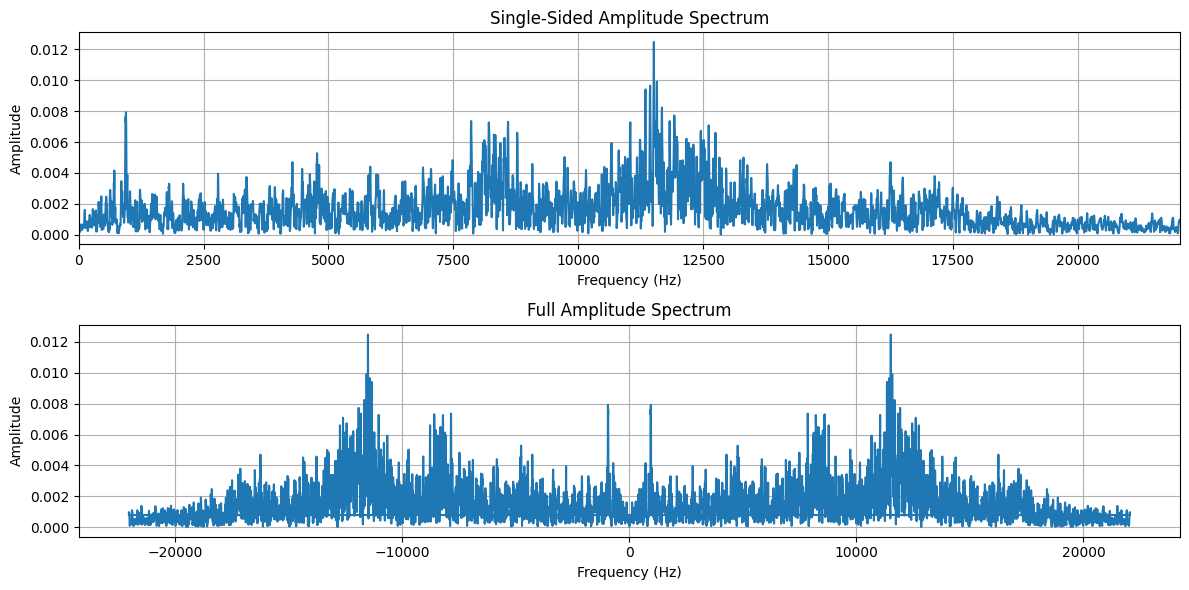


 Gráfico 1 do sinal_taca.wav 


 Gráfico 2 do sinal_taca 



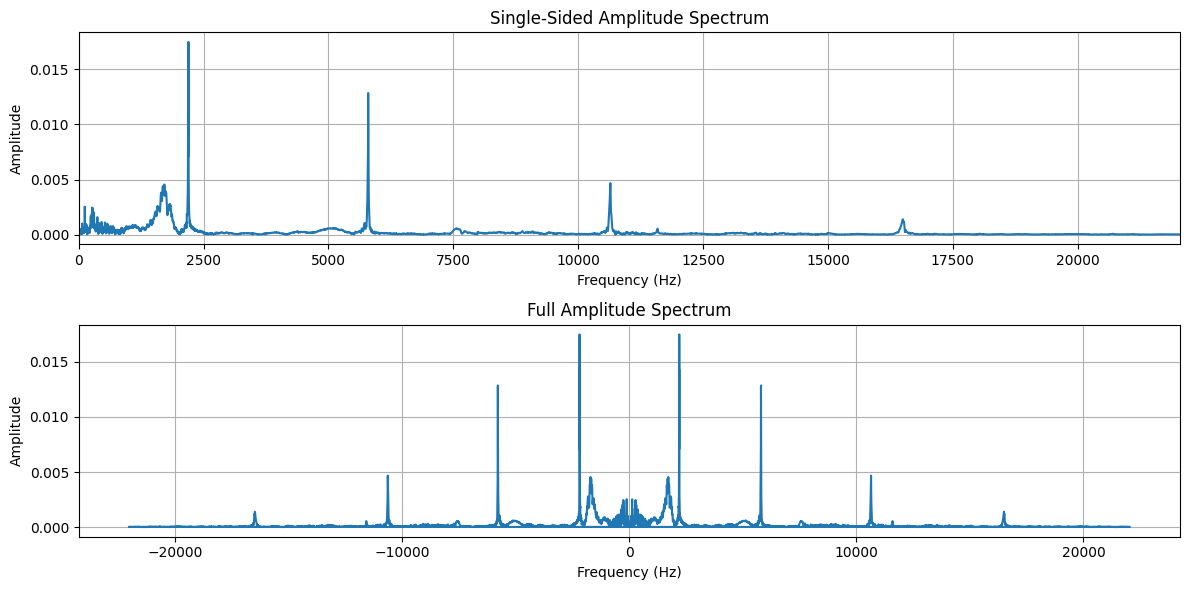

In [ ]:
import numpy as NP
import matplotlib.pyplot as plt
import soundfile as sf
from google.colab import files
from scipy.fft import fft, fftfreq
from scipy.signal import decimate

fs = 44100
t = 1/44100

files.upload()
audioA, file_FSA = sf.read("h_banheiro.wav")
duracao_audioA = len(audioA)/file_FSA

files.upload()
audioB, file_FSB = sf.read("sinal_taca.wav")
duracao_audioB = len(audioB)/file_FSB

#Parte do h_banheiro.wav
def calculate_spectrumA(signal, frequency_sample, single_sided=True):
    N = len(signal) # Number of sample points
    T = 1.0 / 44100 # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes


#0 a 10000
frequencies_single_sided, amplitudes_single_sided = calculate_spectrumA(audioA, fs, single_sided=True)

#-10000 a 10000
frequencies_full, amplitudes_full = calculate_spectrumA(audioA, fs, single_sided=False)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)

print ("\n Gráfico 1 do h_banheiro.wav \n")

plt.plot(frequencies_single_sided, amplitudes_single_sided)
plt.title('Single-Sided Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, fs / 2) # Show frequencies up to Nyquist

plt.subplot(2, 1, 2)

print ("\n Gráfico 2 do h_banheiro.wav \n")

plt.plot(frequencies_full, amplitudes_full)
plt.title('Full Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()

#Parte do sinal_taca.wav
def calculate_spectrumA(signal, frequency_sample, single_sided=True):
    N = len(signal) # Number of sample points
    T = 1.0 / 44100 # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes


#0 a 10000
frequencies_single_sided, amplitudes_single_sided = calculate_spectrumA(audioB, fs, single_sided=True)

#-10000 a 10000
frequencies_full, amplitudes_full = calculate_spectrumA(audioB, fs, single_sided=False)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)

print ("\n Gráfico 1 do sinal_taca.wav \n")

plt.plot(frequencies_single_sided, amplitudes_single_sided)
plt.title('Single-Sided Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, fs / 2) # Show frequencies up to Nyquist

plt.subplot(2, 1, 2)

print ("\n Gráfico 2 do sinal_taca \n")

plt.plot(frequencies_full, amplitudes_full)
plt.title('Full Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()

####**Exercício 10**